In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

df_pca = pd.read_csv('../data/gaia_pca.csv')
df_kmeans = pd.read_csv('../data/gaia_kmeans.csv')
df_dbscan = pd.read_csv('../data/gaia_dbscan.csv')
df_hierarchical = pd.read_csv('../data/gaia_hierarchical.csv')

print("KMeans columns:", df_kmeans.columns.tolist())
print("DBSCAN columns:", df_dbscan.columns.tolist())
print("Hierarchical columns:", df_hierarchical.columns.tolist())

KMeans columns: ['PC1', 'PC2', 'PC3', 'PC4', 'kmeans_cluster']
DBSCAN columns: ['PC1', 'PC2', 'PC3', 'PC4', 'dbscan_cluster']
Hierarchical columns: ['PC1', 'PC2', 'PC3', 'PC4', 'hierarchical_cluster']


In [2]:
sample_size = 10000

kmeans_sample = df_kmeans.sample(sample_size, random_state=42)
kmeans_score = silhouette_score(kmeans_sample[['PC1','PC2','PC3','PC4']], 
                                kmeans_sample['kmeans_cluster'])

df_dbscan_clean = df_dbscan[df_dbscan['dbscan_cluster'] != -1]
dbscan_sample = df_dbscan_clean.sample(sample_size, random_state=42)
dbscan_score = silhouette_score(dbscan_sample[['PC1','PC2','PC3','PC4']], 
                                dbscan_sample['dbscan_cluster'])

hierarchical_score = silhouette_score(df_hierarchical[['PC1','PC2','PC3','PC4']], 
                                      df_hierarchical['hierarchical_cluster'])

print("\nFinal Scores:")
print(f"KMeans:       {kmeans_score:.4f}")
print(f"DBSCAN:       {dbscan_score:.4f}")
print(f"Hierarchical: {hierarchical_score:.4f}")


Final Scores:
KMeans:       0.4823
DBSCAN:       0.4060
Hierarchical: 0.4687


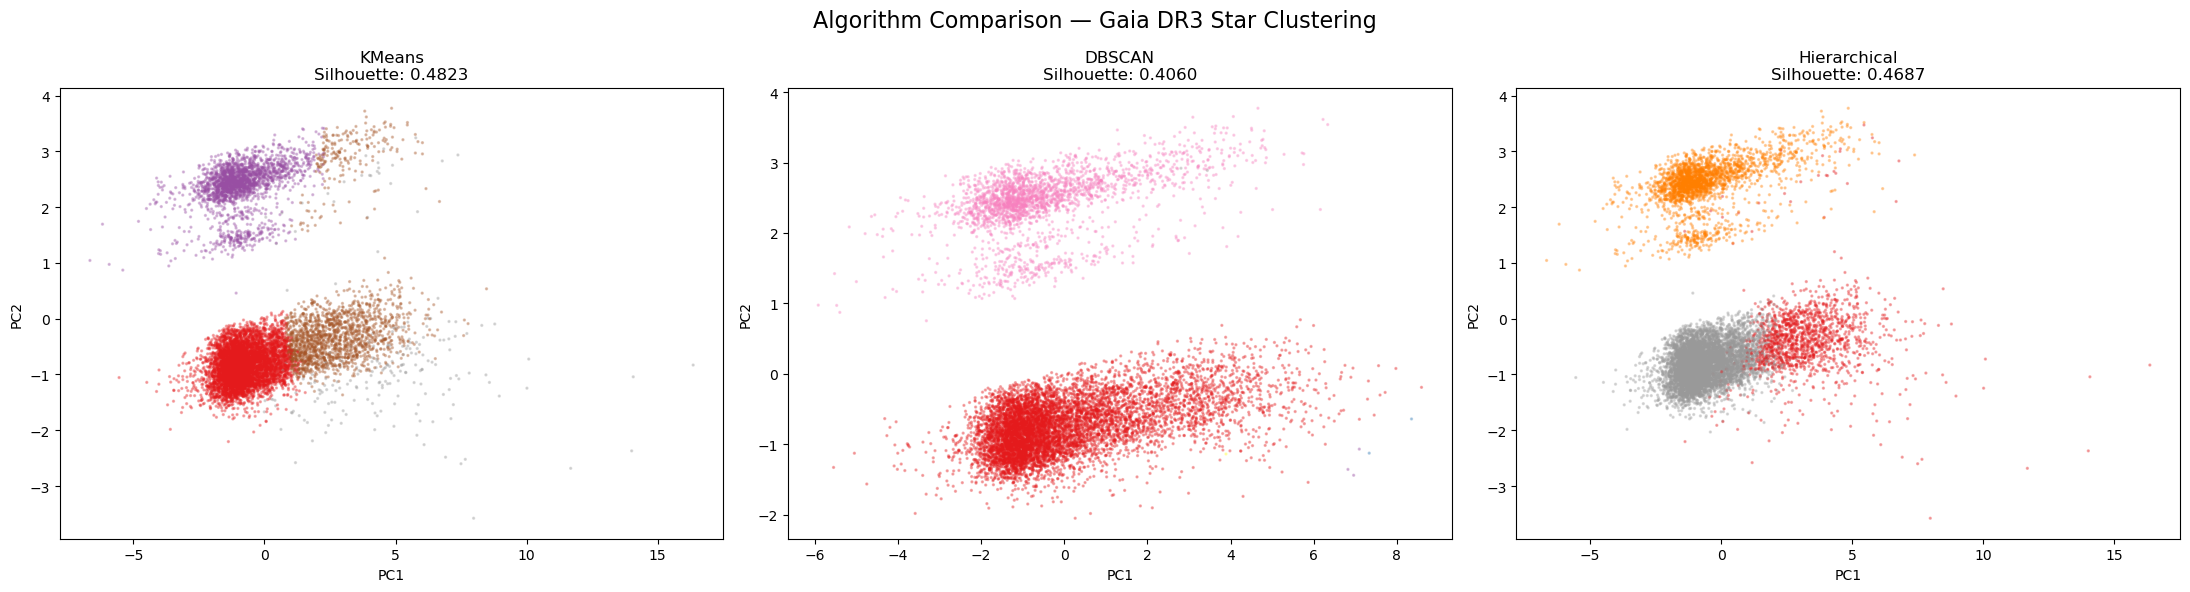

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(kmeans_sample['PC1'], kmeans_sample['PC2'],
                c=kmeans_sample['kmeans_cluster'],
                cmap='Set1', alpha=0.3, s=2)
axes[0].set_title(f'KMeans\nSilhouette: {kmeans_score:.4f}', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(dbscan_sample['PC1'], dbscan_sample['PC2'],
                c=dbscan_sample['dbscan_cluster'],
                cmap='Set1', alpha=0.3, s=2)
axes[1].set_title(f'DBSCAN\nSilhouette: {dbscan_score:.4f}', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

axes[2].scatter(df_hierarchical['PC1'], df_hierarchical['PC2'],
                c=df_hierarchical['hierarchical_cluster'],
                cmap='Set1', alpha=0.3, s=2)
axes[2].set_title(f'Hierarchical\nSilhouette: {hierarchical_score:.4f}', fontsize=12)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.suptitle('Algorithm Comparison — Gaia DR3 Star Clustering', fontsize=16)
plt.tight_layout()
plt.savefig('../images/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()